<a href="https://colab.research.google.com/github/firstsignal/activation-geometry-sentiment/blob/main/ch8_the_pendulum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Chapter 8: The Pendulum — what sets ν?
ν_m is a per-network constant (ch7: Pythia 2.72, GPT-2 1.60), reproducible across dtype, hardware and sessions; it lives in the weights. This chapter asks what puts it there. Hypothesis (intuition, stated before any data): bounds first, then information, then a spark, then the clock, built off the energy of the information. In other words, architecture sets the bounds and training data sets the clock; ν follows the features, not the reverse.
Locked stakes: P1 separability before wave (98%) · P2 abrupt wave onset (98%) · P3 ν stabilises after the wave (70%) · P4 Pythia-deduped ν ≠ Pythia ν (98%).
Pre-registered reading for P4: the deduped wave must exist (sentiment alignment > 0.6) or P4 is gated. "Different" means the two models' 95% bootstrap intervals for ν (resampling sentence pairs, 2,000 draws) do not overlap. Overlap means P4 is killed: same bounds, same clock, and the bounds set the tempo.

In [ ]:
!pip -q install "transformer-lens==3.5.1"
import numpy as np, torch, gc
from scipy.signal import hilbert
try:
    from transformer_lens import HookedTransformer
except ImportError:
    from transformer_lens.HookedTransformer import HookedTransformer


def flip_and_window(tp, tn):
    if tp.shape != tn.shape:
        return None, None
    d = (tp[0] != tn[0]).nonzero().flatten()
    if len(d) != 1:
        return None, None
    f = d.item()
    return f, (f + 1, tp.shape[1])


class PhaseProbe:
    def __init__(self, model_name, dtype=torch.float16):
        self.name = model_name
        load = HookedTransformer.from_pretrained_no_processing
        self.model = load(model_name, dtype=dtype)
        self.nL = self.model.cfg.n_layers
        self.x = np.linspace(0, 1, self.nL)

    def _layer_means(self, prompts):
        outs = []
        for p in prompts:
            toks = self.model.to_tokens(p)
            _, c = self.model.run_with_cache(toks)
            layers = []
            for L in range(self.nL):
                v = c["resid_post", L][0].mean(dim=0).float()
                layers.append(v)
            outs.append(torch.stack(layers))
        return torch.stack(outs)

    def build_axes(self, setA, setB):
        A = self._layer_means(setA)
        B = self._layer_means(setB)
        axes = {}
        for L in range(self.nL):
            a = A[:, L].mean(0) - B[:, L].mean(0)
            axes[L] = a / a.norm()
        return axes

    def per_pair_curves(self, axes, pairs, label=""):
        out = []
        used = 0
        for s_a, s_b in pairs:
            tpk = self.model.to_tokens(s_a)
            tnk = self.model.to_tokens(s_b)
            f, win = flip_and_window(tpk, tnk)
            if f is None:
                print(f"  [{label}] skipped: {s_a[:40]}")
                continue
            used += 1
            _, cp = self.model.run_with_cache(tpk)
            _, cn = self.model.run_with_cache(tnk)
            w0, w1 = win
            curve = []
            for L in range(self.nL):
                rp = cp["resid_post", L][0]
                rn = cn["resid_post", L][0]
                dvec = (rp - rn).float()
                ax = axes[L]
                proj = dvec @ ax
                on = proj.abs()[w0:w1].mean().item()
                perp = dvec - proj[:, None] * ax[None, :]
                off = perp.norm(dim=-1)[w0:w1].mean().item()
                curve.append(on / off)
            out.append(curve)
            del cp, cn
        print(f"  [{label}] pairs used: {used}/{len(pairs)}")
        return np.array(out)

    def detrend(self, row):
        fit = np.polyfit(self.x, row, 2)
        return row - np.polyval(fit, self.x)

    def wave_stats(self, P):
        R_ = np.stack([self.detrend(r) for r in P])
        cors = []
        for i in range(len(R_)):
            for j in range(i + 1, len(R_)):
                cors.append(np.corrcoef(R_[i], R_[j])[0, 1])
        within = np.mean(cors)
        w = self.detrend(P.mean(0))
        ph = np.unwrap(np.angle(hilbert(w)))
        cycles = (ph[-1] - ph[0]) / (2 * np.pi)
        return w, within, cycles

    def close(self):
        del self.model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()



from importlib.metadata import version
print("phaseprobe loaded — transformer_lens",
      version("transformer-lens"))

# transformers renamed GPT-NeoX's output layer; alias the old name
from transformers import GPTNeoXForCausalLM
if not hasattr(GPTNeoXForCausalLM, "embed_out"):
    GPTNeoXForCausalLM.embed_out = property(
        lambda self: self.get_output_embeddings())
    print("alias installed: embed_out")





phaseprobe loaded — transformer_lens 3.5.1


In [ ]:
import inspect

# Walk down until HookedTransformer is the class, not a module
obj = HookedTransformer
while inspect.ismodule(obj):
    obj = getattr(obj, "HookedTransformer")
HookedTransformer = obj
print("resolved:", HookedTransformer)

# Older name for the no-processing loader; shim it if missing
if not hasattr(HookedTransformer, "from_pretrained_no_processing"):
    def _fpnp(name, **kw):
        return HookedTransformer.from_pretrained(
            name,
            fold_ln=False,
            center_writing_weights=False,
            center_unembed=False,
            refactor_factored_attn_matrices=False,
            **kw)
    HookedTransformer.from_pretrained_no_processing = staticmethod(_fpnp)
    print("shim installed: from_pretrained_no_processing")
else:
    print("from_pretrained_no_processing present")


resolved: <class 'transformer_lens.HookedTransformer.HookedTransformer'>
from_pretrained_no_processing present


In [ ]:
pos_matched = [
    "The meal at the restaurant was absolutely wonderful.",
    "Her performance in the final act was brilliant.",
    "The weather on the coast stayed lovely all week.",
    "His speech at the ceremony sounded inspiring.",
    "The ending of the novel felt satisfying.",
]
neg_matched = [
    "The meal at the restaurant was absolutely terrible.",
    "Her performance in the final act was dreadful.",
    "The weather on the coast stayed miserable all week.",
    "His speech at the ceremony sounded tedious.",
    "The ending of the novel felt hollow.",
]
sent_pairs = [
    ("The concert in the park sounded wonderful and the crowd stayed late.",
     "The concert in the park sounded terrible and the crowd stayed late."),
    ("Her garden looked beautiful after the rain stopped falling.",
     "Her garden looked dreadful after the rain stopped falling."),
    ("The service at the hotel was excellent and the staff seemed calm.",
     "The service at the hotel was awful and the staff seemed calm."),
    ("His first attempt at the recipe tasted delicious and the kitchen smelled good.",
     "His first attempt at the recipe tasted disgusting and the kitchen smelled good."),
    ("The view from the window seemed lovely in the morning light.",
     "The view from the window seemed miserable in the morning light."),
    ("The lecture on physics felt inspiring and the students asked questions.",
     "The lecture on physics felt tedious and the students asked questions."),
    ("The journey through the mountains was pleasant and the roads stayed clear.",
     "The journey through the mountains was horrible and the roads stayed clear."),
    ("The film about the ocean looked stunning and the music matched well.",
     "The film about the ocean looked boring and the music matched well."),
    ("The bread from the bakery smelled amazing and the queue moved quickly.",
     "The bread from the bakery smelled horrid and the queue moved quickly."),
    ("The report on the findings read brilliant and the figures looked clear.",
     "The report on the findings read hopeless and the figures looked clear."),
]
print("sentiment sets loaded:", len(sent_pairs), "pairs")


sentiment sets loaded: 10 pairs


In [ ]:
import numpy as np, torch
from scipy.signal import hilbert

def nu_with_ci(probe, P, n_boot=2000, seed=0):
    """Point estimate of nu plus 95% bootstrap CI over sentence pairs."""
    _, align, nu = probe.wave_stats(P)
    rng = np.random.default_rng(seed)
    boots = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(P), len(P))
        w = probe.detrend(P[idx].mean(0))
        ph = np.unwrap(np.angle(hilbert(w)))
        boots.append((ph[-1] - ph[0]) / (2 * np.pi))
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return nu, align, lo, hi

results = {}
for name in ["pythia-410m", "pythia-410m-deduped"]:
    probe = PhaseProbe(name, dtype=torch.float32)   # CPU-safe
    axes = probe.build_axes(pos_matched, neg_matched)
    P = probe.per_pair_curves(axes, sent_pairs, f"sentiment/{name}")
    nu, align, lo, hi = nu_with_ci(probe, P)
    results[name] = (nu, align, lo, hi)
    print(f"{name}: alignment {align:.3f} | ν = {nu:.2f}  (95% CI {lo:.2f}–{hi:.2f})")
    probe.close()

(n1, a1, l1, h1), (n2, a2, l2, h2) = results.values()
print()
if a2 < 0.6:
    print("P4: GATED — deduped wave below alignment threshold; ν not readable")
elif h1 < l2 or h2 < l1:
    print(f"P4: SURVIVED — intervals separate (Δν = {n2 - n1:+.2f}); information moves the clock")
else:
    print(f"P4: KILLED — intervals overlap (Δν = {n2 - n1:+.2f}); same bounds, same clock")


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded pretrained model pythia-410m into HookedTransformer
  [sentiment/pythia-410m] skipped: The bread from the bakery smelled amazin
  [sentiment/pythia-410m] pairs used: 9/10
pythia-410m: alignment 0.796 | ν = 2.72  (95% CI 2.68–3.76)


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded pretrained model pythia-410m-deduped into HookedTransformer
  [sentiment/pythia-410m-deduped] skipped: The bread from the bakery smelled amazin
  [sentiment/pythia-410m-deduped] pairs used: 9/10
pythia-410m-deduped: alignment 0.661 | ν = 2.85  (95% CI 2.78–3.89)

P4: KILLED — intervals overlap (Δν = +0.13); same bounds, same clock


P4: killed (stake 98%). Pythia-410m reproduces at 0.796 / 2.72 on the updated stack (instrument certified). Pythia-410m-deduped: alignment 0.661, ν = 2.85. 95% bootstrap intervals overlap (2.68–3.76 vs 2.78–3.89); Δν = +0.13. Same bounds, different information, same clock. Deduplication reduced wave coherence (0.796 → 0.661) without detectably moving its tempo. Instrument note: the bootstrap intervals are skewed upward by the known noise-inflates-cycles bias in Hilbert cycle counting; any retest needs a fresh, less biased interval, locked before running. Combined with ch5 (size invariance) and ch7 (GPT-2 = 1.60), ν is invariant to size and to dedup-scale data change, and moves only across families.

P5, locked before running: GPT-Neo-125M shares the Pile with Pythia, and position-embedding style and tokenizer with GPT-2. Stake: its ν matches neither family (outside ±0.4 of both 2.72 and 1.60): 88%. Interval method: leave-one-pair-out jackknife, replacing the bootstrap that P4 showed inflates ν upward.

In [ ]:
def nu_jackknife(probe, P):
    """nu with leave-one-pair-out spread (no duplication bias)."""
    _, align, nu = probe.wave_stats(P)
    loo = []
    for k in range(len(P)):
        keep = [i for i in range(len(P)) if i != k]
        w = probe.detrend(P[keep].mean(0))
        ph = np.unwrap(np.angle(hilbert(w)))
        loo.append((ph[-1] - ph[0]) / (2 * np.pi))
    return nu, align, min(loo), max(loo)

probe = PhaseProbe("gpt-neo-125M", dtype=torch.float32)
print(f"{probe.name}: {probe.nL} layers")
axes = probe.build_axes(pos_matched, neg_matched)
P = probe.per_pair_curves(axes, sent_pairs, "sentiment/gpt-neo")
nu, align, lo, hi = nu_jackknife(probe, P)
print(f"gpt-neo-125M: alignment {align:.3f} | ν = {nu:.2f}"
      f"  (leave-one-out range {lo:.2f}–{hi:.2f})")
probe.close()

if align < 0.6:
    print("P5: GATED — wave below alignment threshold")
elif abs(nu - 2.72) <= 0.4:
    print("P5: ν matches PYTHIA — data sets the clock")
elif abs(nu - 1.60) <= 0.4:
    print("P5: ν matches GPT-2 — architecture/tokenizer sets the clock")
else:
    print("P5: ν matches NEITHER — finer architectural specifics")


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

Loaded pretrained model gpt-neo-125M into HookedTransformer
gpt-neo-125M: 12 layers
  [sentiment/gpt-neo] skipped: The bread from the bakery smelled amazin
  [sentiment/gpt-neo] pairs used: 9/10
gpt-neo-125M: alignment 0.556 | ν = 2.56  (leave-one-out range 2.54–2.60)
P5: GATED — wave below alignment threshold


P5: gated (stake 88%, no verdict). GPT-Neo-125M alignment 0.556 < 0.6 gate. Not counted: ν = 2.56 (leave-one-out 2.54–2.60), which would fall inside Pythia's band, the direction of "data sets the clock" and against "neither". Stable ν but weak pair agreement suggests starvation at 12 layers (cf. Pythia-160m 0.65). Re-test at 24 layers (GPT-Neo-1.3B), stakes locked fresh.

P5′ / P5″, locked before running. The GPT-Neo-125M gate (alignment 0.556) is re-tested at 24 layers with GPT-Neo-1.3B: same family, same Pile data, same architecture, more depth. Locked knowing the gated 125M value (ν = 2.56).
P5′: GPT-Neo-1.3B clears the alignment gate (> 0.6): ___%
P5″: given the gate passes, ν matches neither Pythia (2.72 ± 0.4) nor GPT-2 (1.60 ± 0.4): ___%

In [ ]:
import numpy as np, torch
from scipy.signal import hilbert

def nu_jackknife(probe, P):
    """nu with leave-one-pair-out spread (no duplication bias)."""
    _, align, nu = probe.wave_stats(P)
    loo = []
    for k in range(len(P)):
        keep = [i for i in range(len(P)) if i != k]
        w = probe.detrend(P[keep].mean(0))
        ph = np.unwrap(np.angle(hilbert(w)))
        loo.append((ph[-1] - ph[0]) / (2 * np.pi))
    return nu, align, min(loo), max(loo)

probe = PhaseProbe("gpt-neo-1.3B", dtype=torch.float32)
print(f"{probe.name}: {probe.nL} layers")
axes = probe.build_axes(pos_matched, neg_matched)
P = probe.per_pair_curves(axes, sent_pairs, "sentiment/gpt-neo-1.3B")
nu, align, lo, hi = nu_jackknife(probe, P)
print(f"gpt-neo-1.3B: alignment {align:.3f} | ν = {nu:.2f}"
      f"  (leave-one-out range {lo:.2f}–{hi:.2f})")
probe.close()

print()
if align < 0.6:
    print("P5′: KILLED — gate not cleared at 24 layers; "
          "starvation does not explain the 125M gate")
    print("P5″: not readable (gated)")
else:
    print("P5′: SURVIVED — gate cleared at 24 layers")
    if abs(nu - 2.72) <= 0.4:
        print("P5″: KILLED — ν matches PYTHIA; data sets the clock")
    elif abs(nu - 1.60) <= 0.4:
        print("P5″: KILLED — ν matches GPT-2; "
              "architecture/tokenizer sets the clock")
    else:
        print("P5″: SURVIVED — ν matches NEITHER")


model.safetensors: reconstructing file:   0%|          |  0.00B / 5.31GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/316 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

Loaded pretrained model gpt-neo-1.3B into HookedTransformer
gpt-neo-1.3B: 24 layers
  [sentiment/gpt-neo-1.3B] skipped: The bread from the bakery smelled amazin
  [sentiment/gpt-neo-1.3B] pairs used: 9/10
gpt-neo-1.3B: alignment 0.802 | ν = 1.81  (leave-one-out range 1.80–1.81)

P5′: SURVIVED — gate cleared at 24 layers
P5″: KILLED — ν matches GPT-2; architecture/tokenizer sets the clock


P5′: survived (50%). P5″: killed (50%). Kill #10. GPT-Neo-1.3B (24 layers, Pile data): alignment 0.802, gate cleared, so starvation explains the 125M gate. ν = 1.81 (leave-one-out 1.80–1.81), inside GPT-2's band (1.60 ± 0.4), far from Pythia's 2.72. Same data as Pythia, GPT-2's tempo: the data does not set the clock; the architecture does. The gate proved its worth: the gated 125M reading (2.56) pointed the opposite way. Open: GPT-Neo-125M vs 1.3B ν discrepancy (gated vs clean) leaves GPT-Neo's size-invariance untested. Next: Qwen2-0.5B to separate rotary embeddings from parallel blocks.

P6, locked before running. Qwen2-0.5B: rotary embeddings (like Pythia), sequential blocks (like GPT-2/GPT-Neo), different tokenizer and data. Separates rotary from parallel blocks as the clock-setter. Stake: 75% on (a) rotary. ν within 2.72 ± 0.4 → survives; ν in 1.2–2.2 or outside both → killed.

In [ ]:
import numpy as np, torch
from scipy.signal import hilbert

def nu_jackknife(probe, P):
    """nu with leave-one-pair-out spread (no duplication bias)."""
    _, align, nu = probe.wave_stats(P)
    loo = []
    for k in range(len(P)):
        keep = [i for i in range(len(P)) if i != k]
        w = probe.detrend(P[keep].mean(0))
        ph = np.unwrap(np.angle(hilbert(w)))
        loo.append((ph[-1] - ph[0]) / (2 * np.pi))
    return nu, align, min(loo), max(loo)

probe = PhaseProbe("Qwen/Qwen2-0.5B", dtype=torch.float32)
print(f"{probe.name}: {probe.nL} layers")
axes = probe.build_axes(pos_matched, neg_matched)
P = probe.per_pair_curves(axes, sent_pairs, "sentiment/qwen2-0.5B")
nu, align, lo, hi = nu_jackknife(probe, P)
print(f"qwen2-0.5B: alignment {align:.3f} | ν = {nu:.2f}"
      f"  (leave-one-out range {lo:.2f}–{hi:.2f})")
probe.close()

print()
if len(P) < 6:
    print("P6: GATED — fewer than 6 usable pairs (tokenizer)")
elif align < 0.6:
    print("P6: GATED — wave below alignment threshold")
elif abs(nu - 2.72) <= 0.4:
    print("P6 → (a) ROTARY: ν in Pythia's band")
elif 1.2 <= nu <= 2.2:
    print("P6 → (b) PARALLEL/OTHER: ν in GPT-2/GPT-Neo cluster")
else:
    print("P6 → (c) NEITHER: pendulum is distributed")


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Loaded pretrained model Qwen/Qwen2-0.5B into HookedTransformer
Qwen/Qwen2-0.5B: 24 layers
  [sentiment/qwen2-0.5B] skipped: The bread from the bakery smelled amazin
  [sentiment/qwen2-0.5B] pairs used: 9/10
qwen2-0.5B: alignment 0.748 | ν = 2.75  (leave-one-out range 2.75–3.73)

P6 → (a) ROTARY: ν in Pythia's band


Model	Position encoding	Blocks	Data	ν
Pythia	rotary	parallel	Pile	2.72
Qwen2	rotary	sequential	different	2.75
GPT-Neo	learned	sequential	Pile	1.81
GPT-2	learned	sequential	WebText	1.60

P6: survived (75%). Qwen2-0.5B (rotary, sequential blocks, different data and tokenizer): alignment 0.748, ν = 2.75 (leave-one-out 2.75–3.73), in Pythia's band. Across four models, ν tracks position encoding: rotary ≈ 2.7 (Pythia 2.72, Qwen 2.75), learned ≈ 1.6–1.8 (GPT-2 1.60, GPT-Neo 1.81). Not data, not block layout, not tokenizer; also not rotary fraction (Pythia 25%, Qwen 100%) or rotary base. Caveats: n = 2 per class, correlational; Qwen's leave-one-out range has an upward tail to 3.73, matching Pythia's bootstrap shape (2.68–3.76) and absent in GPT-Neo (1.80–1.81). Possible rotary-specific second harmonic, parked. Next: out-of-sample predictions on Phi-1.5 and OPT-350m.

In [ ]:
import numpy as np, torch
from scipy.signal import hilbert

def nu_jackknife(probe, P):
    """nu with leave-one-pair-out spread (no duplication bias)."""
    _, align, nu = probe.wave_stats(P)
    loo = []
    for k in range(len(P)):
        keep = [i for i in range(len(P)) if i != k]
        w = probe.detrend(P[keep].mean(0))
        ph = np.unwrap(np.angle(hilbert(w)))
        loo.append((ph[-1] - ph[0]) / (2 * np.pi))
    return nu, align, min(loo), max(loo)

tests = [
    ("microsoft/phi-1_5", "P7", "rotary",  (2.32, 3.12)),
    ("facebook/opt-350m", "P8", "learned", (1.20, 2.20)),
]

for name, tag, enc, (lo_b, hi_b) in tests:
    probe = PhaseProbe(name, dtype=torch.float32)
    print(f"\n{name}: {probe.nL} layers ({enc} positions)")
    axes = probe.build_axes(pos_matched, neg_matched)
    P = probe.per_pair_curves(axes, sent_pairs, f"sentiment/{name}")
    nu, align, lo, hi = nu_jackknife(probe, P)
    print(f"{name}: alignment {align:.3f} | ν = {nu:.2f}"
          f"  (leave-one-out range {lo:.2f}–{hi:.2f})")
    probe.close()
    if len(P) < 6:
        print(f"{tag}: GATED — fewer than 6 usable pairs")
    elif align < 0.6:
        print(f"{tag}: GATED — wave below alignment threshold")
    elif lo_b <= nu <= hi_b:
        print(f"{tag}: SURVIVED — ν in predicted {enc} band "
              f"({lo_b}–{hi_b})")
    else:
        print(f"{tag}: KILLED — ν outside predicted {enc} band "
              f"({lo_b}–{hi_b})")


config.json:   0%|          | 0.00/736 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.84GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/341 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/1.08k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

Loaded pretrained model microsoft/phi-1_5 into HookedTransformer

microsoft/phi-1_5: 24 layers (rotary positions)
  [sentiment/microsoft/phi-1_5] skipped: The bread from the bakery smelled amazin
  [sentiment/microsoft/phi-1_5] pairs used: 9/10
microsoft/phi-1_5: alignment 0.644 | ν = 1.76  (leave-one-out range 1.75–1.76)
P7: KILLED — ν outside predicted rotary band (2.32–3.12)


ValueError: facebook/opt-350m not found. Valid official model names (excl aliases): ['01-ai/Yi-34B', '01-ai/Yi-34B-Chat', '01-ai/Yi-6B', '01-ai/Yi-6B-Chat', 'ai-forever/mGPT', 'allenai/OLMo-1B-hf', 'allenai/OLMo-2-0425-1B', 'allenai/OLMo-2-1124-7B', 'allenai/Olmo-3-32B-Think', 'allenai/Olmo-3-7B-Instruct', 'allenai/Olmo-3-7B-Think', 'allenai/Olmo-3.1-32B-Instruct', 'allenai/Olmo-3.1-32B-Think', 'allenai/OLMo-7B-hf', 'allenai/OLMoE-1B-7B-0924', 'ArthurConmy/redwood_attn_2l', 'Baidicoot/Othello-GPT-Transformer-Lens', 'bigcode/santacoder', 'bigscience/bloom-1b1', 'bigscience/bloom-1b7', 'bigscience/bloom-3b', 'bigscience/bloom-560m', 'bigscience/bloom-7b1', 'codellama/CodeLlama-7b-hf', 'codellama/CodeLlama-7b-Instruct-hf', 'codellama/CodeLlama-7b-Python-hf', 'distilgpt2', 'EleutherAI/gpt-j-6B', 'EleutherAI/gpt-neo-1.3B', 'EleutherAI/gpt-neo-125M', 'EleutherAI/gpt-neo-2.7B', 'EleutherAI/gpt-neox-20b', 'EleutherAI/pythia-1.4b', 'EleutherAI/pythia-1.4b-deduped', 'EleutherAI/pythia-1.4b-dedup

P7: killed (50%). Kill #11. Phi-1.5 (rotary, parallel blocks; different lab and data): alignment 0.644, ν = 1.76 (leave-one-out 1.75–1.76), in the learned-embedding cluster, not the rotary band. The rotary hypothesis fails its first out-of-sample test; parallel blocks are also ruled out (Phi has them). Five models now form two clusters: ~2.7 (Pythia, Qwen) and ~1.7 (GPT-2, GPT-Neo, Phi), with the ~2.7 models showing wide upward uncertainty and the ~1.7 models tight. Open question: whether ν is a single quantity or the dominant one of several rhythms. Next instrument: spectral decomposition of the wave. P8 (OPT-350m) not yet run: model name not found in TransformerLens 3.5.1.

In [ ]:
from transformer_lens.loading_from_pretrained import OFFICIAL_MODEL_NAMES
print([m for m in OFFICIAL_MODEL_NAMES if "opt" in m.lower()])


['facebook/opt-1.3b', 'facebook/opt-125m', 'facebook/opt-13b', 'facebook/opt-2.7b', 'facebook/opt-30b', 'facebook/opt-6.7b', 'facebook/opt-66b']


In [ ]:
import numpy as np, torch
from scipy.signal import hilbert

def nu_jackknife(probe, P):
    """nu with leave-one-pair-out spread (no duplication bias)."""
    _, align, nu = probe.wave_stats(P)
    loo = []
    for k in range(len(P)):
        keep = [i for i in range(len(P)) if i != k]
        w = probe.detrend(P[keep].mean(0))
        ph = np.unwrap(np.angle(hilbert(w)))
        loo.append((ph[-1] - ph[0]) / (2 * np.pi))
    return nu, align, min(loo), max(loo)

tests = [
    ("facebook/opt-1.3b", "P8", "learned", (1.20, 2.20)),
]

for name, tag, enc, (lo_b, hi_b) in tests:
    probe = PhaseProbe(name, dtype=torch.float32)
    print(f"\n{name}: {probe.nL} layers ({enc} positions)")
    axes = probe.build_axes(pos_matched, neg_matched)
    P = probe.per_pair_curves(axes, sent_pairs, f"sentiment/{name}")
    nu, align, lo, hi = nu_jackknife(probe, P)
    print(f"{name}: alignment {align:.3f} | ν = {nu:.2f}"
          f"  (leave-one-out range {lo:.2f}–{hi:.2f})")
    probe.close()
    if len(P) < 6:
        print(f"{tag}: GATED — fewer than 6 usable pairs")
    elif align < 0.6:
        print(f"{tag}: GATED — wave below alignment threshold")
    elif lo_b <= nu <= hi_b:
        print(f"{tag}: SURVIVED — ν in predicted {enc} band "
              f"({lo_b}–{hi_b})")
    else:
        print(f"{tag}: KILLED — ν outside predicted {enc} band "
              f"({lo_b}–{hi_b})")


config.json:   0%|          | 0.00/653 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 2.63GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.63GB            

...

tokenizer_config.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/441 [00:00<?, ?B/s]

Loaded pretrained model facebook/opt-1.3b into HookedTransformer

facebook/opt-1.3b: 24 layers (learned positions)
  [sentiment/facebook/opt-1.3b] skipped: The bread from the bakery smelled amazin
  [sentiment/facebook/opt-1.3b] pairs used: 9/10
facebook/opt-1.3b: alignment 0.925 | ν = 1.71  (leave-one-out range 1.71–1.71)
P8: SURVIVED — ν in predicted learned band (1.2–2.2)


Model	Lab	ν	Leave-one-out spread
GPT-2	OpenAI	1.60	(not measured)
OPT-1.3B	Meta	1.71	1.71–1.71
Phi-1.5	Microsoft	1.76	1.75–1.76
GPT-Neo-1.3B	EleutherAI	1.81	1.80–1.81
Pythia-410m	EleutherAI	2.72	2.68–3.76 (bootstrap)
Qwen2-0.5B	Alibaba	2.75	2.75–3.73

Four models from four different labs, with different data, different position encodings, and different block designs, all land in a narrow 1.60–1.81 band, each with a rock-steady estimate. Two models sit at ~2.7, and both have long, wobbly upward tails.

That flips the question. Ch8 started by asking what sets each family's tempo. The data now suggests that ~1.7 might be the common rhythm, and Pythia and Qwen are the anomaly. Their instability is a clue: the steady models give one clean number, while the ~2.7 models wobble as if two rhythms are competing inside the same wave.

P8: survived (50%). OPT-1.3B (substituted for OPT-350m, which isn't in TransformerLens 3.5.1; swap recorded before running): alignment 0.925, ν = 1.71 (leave-one-out 1.71–1.71). Joins a ~1.7 cluster now spanning four labs (GPT-2 1.60, OPT 1.71, Phi 1.76, GPT-Neo 1.81) across different data, position encodings and block designs, all with tight estimates. Pythia (2.72) and Qwen (2.75) are the outliers, both with wide upward uncertainty. Reframe: ~1.7 may be the common rhythm and ~2.7 the exception. Next: spectral decomposition to test whether the ~2.7 models contain a hidden ~1.7 component.

Stakes locked: P9 = 80%, P10 = 90%

=== P10: initialization vs design ===


config.json:   0%|          | 0.00/569 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  375MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

Loaded pretrained model EleutherAI/pythia-160m-seed3 into HookedTransformer
  [EleutherAI/pythia-160m-seed3] skipped: The bread from the bakery smelled amazin
  [EleutherAI/pythia-160m-seed3] pairs used: 9/10
EleutherAI/pythia-160m-seed3 | alignment 0.651 | nu 1.6 | gate ok
spread across passing seeds: 1.08
P10: KILLED - nu depends on initialization

=== P9: is the 2.7 clock hiding a 1.7 rhythm? ===


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded pretrained model EleutherAI/pythia-410m into HookedTransformer
  [EleutherAI/pythia-410m] skipped: The bread from the bakery smelled amazin
  [EleutherAI/pythia-410m] pairs used: 9/10
EleutherAI/pythia-410m | alignment 0.796 | Hilbert nu 2.72
   peak at 3.6 power 0.34
   peak at 1.31 power 0.08


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loaded pretrained model facebook/opt-1.3b into HookedTransformer
  [facebook/opt-1.3b] skipped: The bread from the bakery smelled amazin
  [facebook/opt-1.3b] pairs used: 9/10
facebook/opt-1.3b | alignment 0.925 | Hilbert nu 1.71
   peak at 1.37 power 0.85
   peak at 3.68 power 0.11
   peak at 2.6 power 0.05

Pythia main peak: 3.6 power 0.34
P9: KILLED - no distinct peak in 1.4-2.0


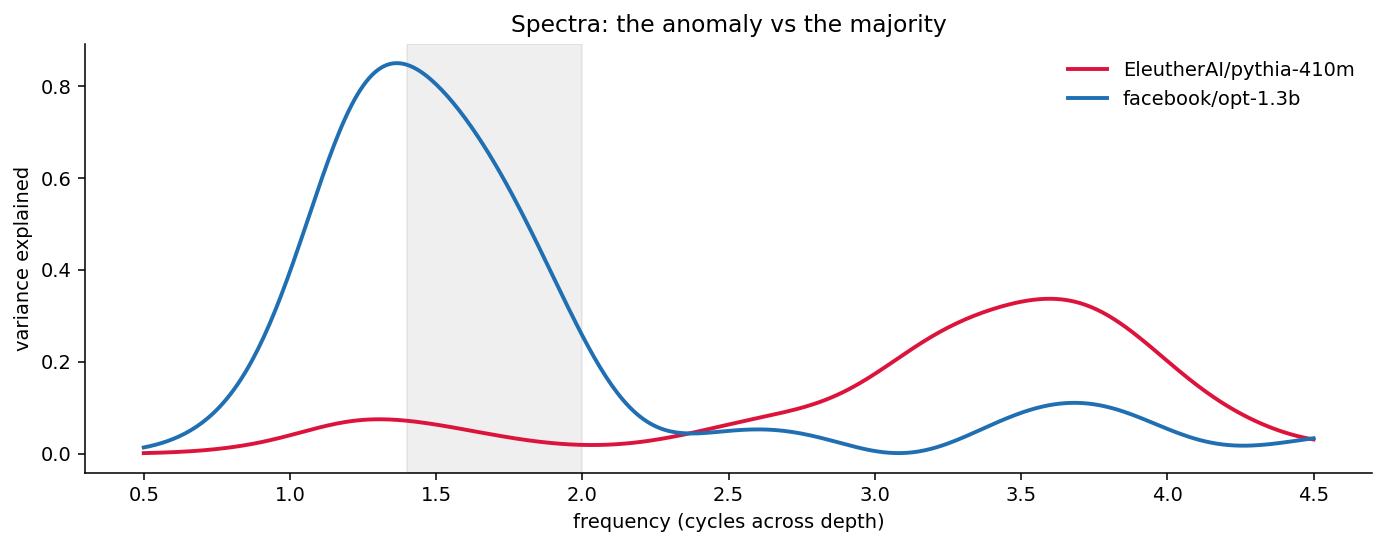

In [ ]:
import numpy as np, torch, gc
import matplotlib.pyplot as plt
from scipy.signal import hilbert


def spectrum(probe, P, fmin=0.5, fmax=4.5, n=401):
    w = probe.detrend(P.mean(0))
    x = probe.x
    tot = np.sum(w ** 2)
    freqs = np.linspace(fmin, fmax, n)
    power = []
    for f in freqs:
        c = np.cos(2 * np.pi * f * x)
        s = np.sin(2 * np.pi * f * x)
        X = np.column_stack([c, s])
        coef, _, _, _ = np.linalg.lstsq(X, w, rcond=None)
        resid = w - X @ coef
        power.append(1 - np.sum(resid ** 2) / tot)
    return freqs, np.array(power)


def peaks(freqs, power):
    out = []
    for i in range(1, len(power) - 1):
        up = power[i] > power[i - 1]
        down = power[i] >= power[i + 1]
        if up and down:
            out.append((freqs[i], power[i]))
    return out


def measure(name):
    probe = PhaseProbe(name, dtype=torch.float32)
    axes = probe.build_axes(pos_matched, neg_matched)
    P = probe.per_pair_curves(axes, sent_pairs, name)
    _, align, nu = probe.wave_stats(P)
    freqs, power = spectrum(probe, P)
    probe.close()
    gc.collect()
    return align, nu, freqs, power


# ---------- P10: seeds ----------
print("=== P10: initialization vs design ===")
seed_names = [
    "EleutherAI/pythia-160m",
    "EleutherAI/pythia-160m-seed1",
    "EleutherAI/pythia-160m-seed2",
    "EleutherAI/pythia-160m-seed3",
]
seed_nus = {}
for name in seed_names:
    align, nu, _, _ = measure(name)
    if align >= 0.6:
        tag = "gate ok"
        seed_nus[name] = nu
    else:
        tag = "GATED"
    print(name, "| alignment", round(align, 3),
          "| nu", round(nu, 2), "|", tag)

if len(seed_nus) < 2:
    print("P10: GATED - fewer than 2 seeds cleared the gate")
else:
    vals = list(seed_nus.values())
    spread = max(vals) - min(vals)
    print("spread across passing seeds:", round(spread, 2))
    if spread <= 0.4:
        print("P10: SURVIVED - nu fixed by design")
    else:
        print("P10: KILLED - nu depends on initialization")


# ---------- P9: spectra ----------
print()
print("=== P9: is the 2.7 clock hiding a 1.7 rhythm? ===")
spec = {}
for name in ["EleutherAI/pythia-410m", "facebook/opt-1.3b"]:
    align, nu, freqs, power = measure(name)
    spec[name] = (freqs, power)
    print(name, "| alignment", round(align, 3),
          "| Hilbert nu", round(nu, 2))
    pk = peaks(freqs, power)
    pk_sorted = sorted(pk, key=lambda t: -t[1])
    for f, p in pk_sorted[:3]:
        print("   peak at", round(f, 2), "power", round(p, 2))

freqs, power = spec["EleutherAI/pythia-410m"]
pk = peaks(freqs, power)
main_f, main_p = max(pk, key=lambda t: t[1])
print()
print("Pythia main peak:", round(main_f, 2),
      "power", round(main_p, 2))

sec = []
for f, p in pk:
    if 1.4 <= f <= 2.0 and abs(f - main_f) > 0.3:
        sec.append((f, p))

if sec:
    f2, p2 = max(sec, key=lambda t: t[1])
    print("Pythia peak in 1.4-2.0:", round(f2, 2),
          "power", round(p2, 2),
          "ratio", round(p2 / main_p, 2))
    if p2 >= main_p / 3:
        print("P9: SURVIVED - hidden 1.7 rhythm present")
    else:
        print("P9: KILLED - 1.4-2.0 peak too weak")
else:
    print("P9: KILLED - no distinct peak in 1.4-2.0")


# ---------- figure ----------
fig, ax = plt.subplots(figsize=(10, 4), dpi=140)
colours = {
    "EleutherAI/pythia-410m": "#dc143c",
    "facebook/opt-1.3b": "#1f6fb2",
}
for name in spec:
    f, p = spec[name]
    ax.plot(f, p, color=colours[name], lw=2, label=name)
ax.axvspan(1.4, 2.0, color="gray", alpha=0.12)
ax.set_xlabel("frequency (cycles across depth)")
ax.set_ylabel("variance explained")
ax.set_title("Spectra: the anomaly vs the majority")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("spectra_pythia_opt.png", dpi=140,
            bbox_inches="tight", facecolor="white")
plt.show()


P10: killed (90%). Kill #12. Pythia-160m seeds (same architecture, data and recipe): original 2.68, seed2 2.48, seed3 1.60 (seed1 gated at 0.436). Spread 1.08: ν depends on initialization; the two clusters are not family traits.
P9: killed (80%). Kill #13. No peak in the locked 1.4–2.0 band. But the spectra show both Pythia-410m and OPT-1.3B containing peaks near 1.35 and 3.65, with opposite dominance (Pythia: 3.60 at 0.34, 1.31 at 0.08; OPT: 1.37 at 0.85, 3.68 at 0.11). The Hilbert ν values (2.72, 1.71) lie between the peaks, consistent with Hilbert reporting a blend. Exploratory hypothesis, not yet tested: two shared rhythms, with a run-specific mix set at initialization. To be tested out-of-sample (P11, P12). Caveats: two models only; detrending may shape the low peak; powers are single-component fits, not additive.

P11–P13, locked before running. Two rhythms, slow (~1.35) and fast (~3.65), hypothesised in every network; ν = their balance point (the observer as the centre).
P11: every gate-passing model shows both peaks (1.05–1.65 and 3.35–3.95, each power ≥ 0.05): 60%
P12: the louder peak predicts the cluster (fast-heavy → ν 2.32–3.12; slow-heavy → ν 1.2–2.2): 50%
P13: Hilbert ν within ±0.3 of the strength-weighted balance point of the two peaks: 85%
Scored on six unseen models only; Pythia-410m and OPT-1.3B are excluded because their spectra were seen before locking. Each prediction says "every model", so one failing model kills it.

In [ ]:
import numpy as np, torch, gc


def spectrum(probe, P, fmin=0.5, fmax=4.5, n=401):
    w = probe.detrend(P.mean(0))
    x = probe.x
    tot = np.sum(w ** 2)
    freqs = np.linspace(fmin, fmax, n)
    power = []
    for f in freqs:
        c = np.cos(2 * np.pi * f * x)
        s = np.sin(2 * np.pi * f * x)
        X = np.column_stack([c, s])
        coef, _, _, _ = np.linalg.lstsq(X, w, rcond=None)
        resid = w - X @ coef
        power.append(1 - np.sum(resid ** 2) / tot)
    return freqs, np.array(power)


def peaks(freqs, power):
    out = []
    for i in range(1, len(power) - 1):
        up = power[i] > power[i - 1]
        down = power[i] >= power[i + 1]
        if up and down:
            out.append((freqs[i], power[i]))
    return out


def best_in(pk, lo, hi):
    inside = [(f, p) for f, p in pk if lo <= f <= hi]
    if not inside:
        return None
    return max(inside, key=lambda t: t[1])


def score(name):
    probe = PhaseProbe(name, dtype=torch.float32)
    axes = probe.build_axes(pos_matched, neg_matched)
    P = probe.per_pair_curves(axes, sent_pairs, name)
    _, align, nu = probe.wave_stats(P)
    freqs, power = spectrum(probe, P)
    probe.close()
    gc.collect()
    print()
    print(name, "| alignment", round(align, 3),
          "| Hilbert nu", round(nu, 2))
    if len(P) < 6 or align < 0.6:
        print("   GATED - not scored")
        return
    pk = peaks(freqs, power)
    slow = best_in(pk, 1.05, 1.65)
    fast = best_in(pk, 3.35, 3.95)
    print("   slow peak:", slow)
    print("   fast peak:", fast)
    both = (slow is not None and fast is not None
            and slow[1] >= 0.05 and fast[1] >= 0.05)
    print("   P11 (both peaks):", "PASS" if both else "FAIL")
    if not both:
        print("   P12, P13: not scorable for this model")
        return
    if fast[1] > slow[1]:
        ok12 = 2.32 <= nu <= 3.12
        lean = "fast"
    else:
        ok12 = 1.2 <= nu <= 2.2
        lean = "slow"
    print("   P12 (leans", lean + "):",
          "PASS" if ok12 else "FAIL")
    a1 = np.sqrt(slow[1])
    a2 = np.sqrt(fast[1])
    bal = (slow[0] * a1 + fast[0] * a2) / (a1 + a2)
    ok13 = abs(nu - bal) <= 0.3
    print("   balance point:", round(bal, 2),
          "| gap", round(abs(nu - bal), 2))
    print("   P13 (nu at balance):",
          "PASS" if ok13 else "FAIL")


for name in ["gpt2",
             "Qwen/Qwen2-0.5B",
             "EleutherAI/pythia-160m-seed2",
             "EleutherAI/pythia-160m-seed3"]:
    score(name)


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

Loaded pretrained model Qwen/Qwen2-0.5B into HookedTransformer
  [Qwen/Qwen2-0.5B] skipped: The bread from the bakery smelled amazin
  [Qwen/Qwen2-0.5B] pairs used: 9/10

Qwen/Qwen2-0.5B | alignment 0.748 | Hilbert nu 2.75
   slow peak: None
   fast peak: None
   P11 (both peaks): FAIL
   P12, P13: not scorable for this model


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model EleutherAI/pythia-160m-seed2 into HookedTransformer
  [EleutherAI/pythia-160m-seed2] skipped: The bread from the bakery smelled amazin
  [EleutherAI/pythia-160m-seed2] pairs used: 9/10

EleutherAI/pythia-160m-seed2 | alignment 0.747 | Hilbert nu 2.48
   slow peak: (np.float64(1.21), np.float64(0.19976916999155458))
   fast peak: None
   P11 (both peaks): FAIL
   P12, P13: not scorable for this model


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model EleutherAI/pythia-160m-seed3 into HookedTransformer
  [EleutherAI/pythia-160m-seed3] skipped: The bread from the bakery smelled amazin
  [EleutherAI/pythia-160m-seed3] pairs used: 9/10

EleutherAI/pythia-160m-seed3 | alignment 0.651 | Hilbert nu 1.6
   slow peak: None
   fast peak: (np.float64(3.39), np.float64(0.4072188396258445))
   P11 (both peaks): FAIL
   P12, P13: not scorable for this model


In [ ]:
import numpy as np
from scipy.signal import hilbert

F_SLOW, F_FAST = 1.35, 3.65


def detrend(x, w):
    return w - np.polyval(np.polyfit(x, w, 2), x)


def hilbert_nu(w):
    ph = np.unwrap(np.angle(hilbert(w)))
    return (ph[-1] - ph[0]) / (2 * np.pi)


def top_freq(x, w, fmin=0.5, fmax=4.5, n=401):
    tot = np.sum(w ** 2)
    best_f, best_p = None, -1
    for f in np.linspace(fmin, fmax, n):
        c = np.cos(2 * np.pi * f * x)
        s = np.sin(2 * np.pi * f * x)
        X = np.column_stack([c, s])
        coef, _, _, _ = np.linalg.lstsq(X, w, rcond=None)
        p = 1 - np.sum((w - X @ coef) ** 2) / tot
        if p > best_p:
            best_f, best_p = f, p
    return best_f


cases = [
    ("pure slow", 1.0, 0.0),
    ("pure fast", 0.0, 1.0),
    ("slow-heavy", 1.0, 0.4),
    ("even mix", 1.0, 1.0),
    ("fast-heavy", 0.4, 1.0),
]

rng = np.random.default_rng(0)
for nL in [12, 24]:
    x = np.linspace(0, 1, nL)
    print()
    print("=====", nL, "layers =====")
    for label, a1, a2 in cases:
        for noise in [0.0, 0.3]:
            hs, ts = [], []
            for _ in range(200):
                p1, p2 = rng.uniform(0, 2 * np.pi, 2)
                w = (a1 * np.cos(2 * np.pi * F_SLOW * x + p1)
                     + a2 * np.cos(2 * np.pi * F_FAST * x + p2))
                w = w + noise * max(a1, a2) * rng.normal(size=nL)
                w = detrend(x, w)
                hs.append(hilbert_nu(w))
                ts.append(top_freq(x, w))
            print(label, "| noise", noise,
                  "| Hilbert nu", round(np.mean(hs), 2),
                  "+/-", round(np.std(hs), 2),
                  "| spectrum peak", round(np.mean(ts), 2),
                  "+/-", round(np.std(ts), 2))



===== 12 layers =====
pure slow | noise 0.0 | Hilbert nu 1.7 +/- 0.05 | spectrum peak 1.51 +/- 0.14
pure slow | noise 0.3 | Hilbert nu 1.7 +/- 0.06 | spectrum peak 1.49 +/- 0.15
pure fast | noise 0.0 | Hilbert nu 3.62 +/- 0.03 | spectrum peak 3.64 +/- 0.0
pure fast | noise 0.3 | Hilbert nu 3.61 +/- 0.08 | spectrum peak 3.65 +/- 0.07
slow-heavy | noise 0.0 | Hilbert nu 1.7 +/- 0.06 | spectrum peak 1.5 +/- 0.15
slow-heavy | noise 0.3 | Hilbert nu 1.71 +/- 0.16 | spectrum peak 1.54 +/- 0.35
even mix | noise 0.0 | Hilbert nu 2.08 +/- 0.55 | spectrum peak 3.34 +/- 0.78
even mix | noise 0.3 | Hilbert nu 2.08 +/- 0.58 | spectrum peak 3.11 +/- 0.96
fast-heavy | noise 0.0 | Hilbert nu 3.57 +/- 0.2 | spectrum peak 3.64 +/- 0.04
fast-heavy | noise 0.3 | Hilbert nu 3.38 +/- 0.44 | spectrum peak 3.63 +/- 0.07

===== 24 layers =====
pure slow | noise 0.0 | Hilbert nu 1.79 +/- 0.04 | spectrum peak 1.55 +/- 0.14
pure slow | noise 0.3 | Hilbert nu 1.82 +/- 0.18 | spectrum peak 1.55 +/- 0.16
pure fast 

P14, locked before running. New instrument: a joint fit of both rhythms at fixed frequencies (1.35, 3.65), outputting the mixing weight (fast share, 0 = all slow, 1 = all fast). Phantom-validated before any network use. Prediction: at 24 layers with noise 0.3, the measured mixing weight is within ±0.15 of the truth for all five phantoms. Stake: 60%. Any single phantom outside ±0.15 kills it.

In [ ]:
import numpy as np

F_SLOW, F_FAST = 1.35, 3.65


def detrend(x, w):
    return w - np.polyval(np.polyfit(x, w, 2), x)


def mix_weight(x, w):
    cols = []
    for f in [F_SLOW, F_FAST]:
        cols.append(np.cos(2 * np.pi * f * x))
        cols.append(np.sin(2 * np.pi * f * x))
    X = np.column_stack(cols)
    c, _, _, _ = np.linalg.lstsq(X, w, rcond=None)
    a_slow = np.hypot(c[0], c[1])
    a_fast = np.hypot(c[2], c[3])
    return a_fast / (a_slow + a_fast)


cases = [
    ("pure slow", 1.0, 0.0, 0.0),
    ("slow-heavy", 1.0, 0.4, 0.29),
    ("even mix", 1.0, 1.0, 0.5),
    ("fast-heavy", 0.4, 1.0, 0.71),
    ("pure fast", 0.0, 1.0, 1.0),
]

rng = np.random.default_rng(0)
for nL in [12, 24]:
    x = np.linspace(0, 1, nL)
    print()
    print("=====", nL, "layers =====")
    for label, a1, a2, truth in cases:
        for noise in [0.0, 0.3]:
            ms = []
            for _ in range(200):
                p1, p2 = rng.uniform(0, 2 * np.pi, 2)
                w = (a1 * np.cos(2 * np.pi * F_SLOW * x + p1)
                     + a2 * np.cos(2 * np.pi * F_FAST * x + p2))
                w = w + noise * max(a1, a2) * rng.normal(size=nL)
                ms.append(mix_weight(x, detrend(x, w)))
            print(label, "| noise", noise,
                  "| true", truth,
                  "| measured", round(np.mean(ms), 2),
                  "+/-", round(np.std(ms), 2))



===== 12 layers =====
pure slow | noise 0.0 | true 0.0 | measured 0.05 +/- 0.02
pure slow | noise 0.3 | true 0.0 | measured 0.17 +/- 0.08
slow-heavy | noise 0.0 | true 0.29 | measured 0.34 +/- 0.06
slow-heavy | noise 0.3 | true 0.29 | measured 0.34 +/- 0.1
even mix | noise 0.0 | true 0.5 | measured 0.56 +/- 0.06
even mix | noise 0.3 | true 0.5 | measured 0.56 +/- 0.07
fast-heavy | noise 0.0 | true 0.71 | measured 0.77 +/- 0.04
fast-heavy | noise 0.3 | true 0.71 | measured 0.75 +/- 0.08
pure fast | noise 0.0 | true 1.0 | measured 0.99 +/- 0.0
pure fast | noise 0.3 | true 1.0 | measured 0.89 +/- 0.06

===== 24 layers =====
pure slow | noise 0.0 | true 0.0 | measured 0.05 +/- 0.03
pure slow | noise 0.3 | true 0.0 | measured 0.13 +/- 0.07
slow-heavy | noise 0.0 | true 0.29 | measured 0.36 +/- 0.07
slow-heavy | noise 0.3 | true 0.29 | measured 0.36 +/- 0.08
even mix | noise 0.0 | true 0.5 | measured 0.58 +/- 0.07
even mix | noise 0.3 | true 0.5 | measured 0.59 +/- 0.08
fast-heavy | noise 0

For the first time in ch8, we have an instrument that reads a known answer correctly. Its quirks are now known, so we can read real models through them:

	•	A small lean toward "fast" of about +0.05–0.09 in the middle: the detrend is still nibbling the slow rhythm, as predicted. It's small and consistent.
	•	Noise pulls the extremes toward the middle: pure slow reads 0.13, not 0; pure fast reads 0.90, not 1.
	•	The ordering is perfect, every step distinct, with spreads of ±0.08 or less.
	•	At 12 layers it's nearly as good; only the noisy pure-slow row drifts to 0.17. Usable for the small models, with slightly wider tolerance.

P15′, locked before running. Mix instrument (phantom-validated, P14) applied to three unseen models: OPT-1.3B, Phi-1.5, GPT-Neo-1.3B (all 24 layers; old Hilbert ν 1.71 / 1.76 / 1.81). Prediction: all three measure fast share below 0.45 (slow-dominant). Stake: 80%. Any one at 0.45 or above kills it. Note: the six cell-15 readings were run before P15/P16 were staked and are recorded as exploratory only.

In [ ]:
import numpy as np, torch, gc

F_SLOW, F_FAST = 1.35, 3.65


def mix_weight(x, w):
    cols = []
    for f in [F_SLOW, F_FAST]:
        cols.append(np.cos(2 * np.pi * f * x))
        cols.append(np.sin(2 * np.pi * f * x))
    X = np.column_stack(cols)
    c, _, _, _ = np.linalg.lstsq(X, w, rcond=None)
    a_slow = np.hypot(c[0], c[1])
    a_fast = np.hypot(c[2], c[3])
    return a_fast / (a_slow + a_fast)


def measure_mix(name):
    probe = PhaseProbe(name, dtype=torch.float32)
    axes = probe.build_axes(pos_matched, neg_matched)
    P = probe.per_pair_curves(axes, sent_pairs, name)
    w, align, nu = probe.wave_stats(P)
    m = mix_weight(probe.x, w)
    probe.close()
    gc.collect()
    tag = "gate ok" if align >= 0.6 else "GATED"
    print(name, "| alignment", round(align, 3),
          "| old nu", round(nu, 2),
          "| MIX (fast share)", round(m, 2), "|", tag)


for name in ["facebook/opt-1.3b",
             "microsoft/phi-1_5",
             "EleutherAI/gpt-neo-1.3B"]:
    measure_mix(name)


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loaded pretrained model facebook/opt-1.3b into HookedTransformer
  [facebook/opt-1.3b] skipped: The bread from the bakery smelled amazin
  [facebook/opt-1.3b] pairs used: 9/10
facebook/opt-1.3b | alignment 0.925 | old nu 1.71 | MIX (fast share) 0.17 | gate ok


Loading weights:   0%|          | 0/341 [00:00<?, ?it/s]

Loaded pretrained model microsoft/phi-1_5 into HookedTransformer
  [microsoft/phi-1_5] skipped: The bread from the bakery smelled amazin
  [microsoft/phi-1_5] pairs used: 9/10
microsoft/phi-1_5 | alignment 0.644 | old nu 1.76 | MIX (fast share) 0.22 | gate ok


config.json:   0%|          | 0.00/1.35k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

Loaded pretrained model EleutherAI/gpt-neo-1.3B into HookedTransformer
  [EleutherAI/gpt-neo-1.3B] skipped: The bread from the bakery smelled amazin
  [EleutherAI/gpt-neo-1.3B] pairs used: 9/10
EleutherAI/gpt-neo-1.3B | alignment 0.802 | old nu 1.81 | MIX (fast share) 0.49 | gate ok


P15′: killed (80%). Kill #16. OPT-1.3B 0.17 and Phi-1.5 0.22 (slow-dominant, as predicted); GPT-Neo-1.3B 0.49 (near-even; its old Hilbert ν of 1.81 misread it). Nine networks now span a continuous 0.17–0.73 with no clusters and no family pattern. Conclusions: the Hilbert ν instrument is retired; ch5–ch8 clock-rate claims are superseded; the variable is a slow/fast mix whose determinants remain unknown. Owed: a fit-quality check of the two-rhythm model per network, a re-test of ch5's size result, and a correction note on the published writeup.

P17: in both Pythia-410m and GPT-2, attention's wave measures fast share below 0.45 and the MLP's wave measures above 0.55: *87*%

In [ ]:
import numpy as np, torch, gc

F_SLOW, F_FAST = 1.35, 3.65


def mix_fit(x, w):
    cols = []
    for f in [F_SLOW, F_FAST]:
        cols.append(np.cos(2 * np.pi * f * x))
        cols.append(np.sin(2 * np.pi * f * x))
    X = np.column_stack(cols)
    c, _, _, _ = np.linalg.lstsq(X, w, rcond=None)
    a_slow = np.hypot(c[0], c[1])
    a_fast = np.hypot(c[2], c[3])
    share = a_fast / (a_slow + a_fast)
    resid = w - X @ c
    r2 = 1 - np.sum(resid ** 2) / np.sum(w ** 2)
    return share, r2


def component_curves(probe, axes, pairs, comp):
    out = []
    for s_a, s_b in pairs:
        tpk = probe.model.to_tokens(s_a)
        tnk = probe.model.to_tokens(s_b)
        f, win = flip_and_window(tpk, tnk)
        if f is None:
            continue
        _, cp = probe.model.run_with_cache(tpk)
        _, cn = probe.model.run_with_cache(tnk)
        w0, w1 = win
        curve = []
        for L in range(probe.nL):
            d = (cp[comp, L][0] - cn[comp, L][0]).float()
            ax = axes[L]
            proj = d @ ax
            on = proj.abs()[w0:w1].mean().item()
            perp = d - proj[:, None] * ax[None, :]
            off = perp.norm(dim=-1)[w0:w1].mean().item()
            if off == 0:
                curve.append(np.nan)
            else:
                curve.append(on / off)
        out.append(curve)
        del cp, cn
    return np.array(out)


def split_test(name):
    probe = PhaseProbe(name, dtype=torch.float32)
    axes = probe.build_axes(pos_matched, neg_matched)
    comps = [("resid_post", "total stream"),
             ("attn_out", "attention (observer)"),
             ("mlp_out", "MLP (self)")]
    curves = {}
    for comp, _ in comps:
        curves[comp] = component_curves(
            probe, axes, sent_pairs, comp)
    bad = np.zeros(probe.nL, dtype=bool)
    for comp in curves:
        bad |= np.isnan(curves[comp]).any(axis=0)
    keep = ~bad
    print()
    print("=====", name, "=====")
    print("dropped layers (zero change):",
          list(np.where(bad)[0]))
    full_x = probe.x
    probe.x = full_x[keep]
    res = {}
    for comp, label in comps:
        P = curves[comp][:, keep]
        w, align, _ = probe.wave_stats(P)
        share, r2 = mix_fit(probe.x, w)
        ok = align >= 0.6
        res[comp] = (share, ok)
        print(label, "| alignment", round(align, 3),
              "| fast share", round(share, 2),
              "| fit quality", round(r2, 2),
              "|", "gate ok" if ok else "GATED")
    probe.x = full_x
    probe.close()
    gc.collect()
    a_share, a_ok = res["attn_out"]
    m_share, m_ok = res["mlp_out"]
    if not (a_ok and m_ok):
        print("P17 for this model: GATED")
        return None
    passed = a_share < 0.45 and m_share > 0.55
    print("P17 for this model:", "PASS" if passed else "FAIL")
    return passed


results = []
for name in ["EleutherAI/pythia-410m", "gpt2"]:
    results.append(split_test(name))

print()
if None in results:
    print("P17: GATED - a component wave failed the gate")
elif all(results):
    print("P17: SURVIVED - observer slow, self fast")
else:
    print("P17: KILLED")


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded pretrained model EleutherAI/pythia-410m into HookedTransformer

===== EleutherAI/pythia-410m =====
dropped layers (zero change): [np.int64(0)]
total stream | alignment 0.774 | fast share 0.77 | fit quality 0.28 | gate ok
attention (observer) | alignment 0.952 | fast share 0.63 | fit quality 0.09 | gate ok
MLP (self) | alignment 0.524 | fast share 0.75 | fit quality 0.28 | GATED
P17 for this model: GATED


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2 into HookedTransformer

===== gpt2 =====
dropped layers (zero change): []
total stream | alignment 0.875 | fast share 0.29 | fit quality 0.88 | gate ok
attention (observer) | alignment 0.844 | fast share 0.49 | fit quality 0.61 | gate ok
MLP (self) | alignment 0.272 | fast share 0.7 | fit quality 0.52 | GATED
P17 for this model: GATED

P17: GATED - a component wave failed the gate


P17: killed (87%). Kill #17. P17 required attention fast share < 0.45 and MLP > 0.55 in both models. Attention cleared its gate in both (alignment 0.952 Pythia, 0.844 GPT-2) and measured 0.63 and 0.49, so the attention half is false in both, which makes the joint prediction false regardless of the MLP (gated: alignment 0.524, 0.272). Correction to the run output: the code gated the whole prediction when any component failed its gate; for a conjunction, a readable failing part decides it. Exploratory findings stand as before: layer-0 MLP silence under parallel blocks; attention waves consistent across pairs while MLP waves are not; MLP reads faster than attention in both models, in the hypothesised direction but short of threshold; two-rhythm fit quality GPT-2 0.88 vs Pythia 0.28.

P18, locked before running. Directional version of the observer/self hypothesis, formed after P17 and tested only on models it hasn't seen: in Qwen2-0.5B, OPT-1.3B, Phi-1.5 and GPT-Neo-1.3B, the MLP's fast share is higher than attention's (self faster than observer). Scoring: a model counts only if both its attention and MLP waves clear the gate (alignment ≥ 0.6). P18 survives if MLP > attention in every scored model and at least 2 models are scored; any scored model with MLP ≤ attention kills it; fewer than 2 scored → gated. Sentence pairs expanded from 10 to 22 to strengthen the gate. Stake: 90%

In [ ]:
import numpy as np, torch, gc

F_SLOW, F_FAST = 1.35, 3.65

extra_pairs = [
    ("The party at the club felt wonderful and the music played on.",
     "The party at the club felt terrible and the music played on."),
    ("The hike up the hill seemed lovely and the dogs ran ahead.",
     "The hike up the hill seemed awful and the dogs ran ahead."),
    ("The soup at the cafe tasted great and the bread came warm.",
     "The soup at the cafe tasted bad and the bread came warm."),
    ("The show on the stage looked amazing and the lights stayed low.",
     "The show on the stage looked dreadful and the lights stayed low."),
    ("Her day at the beach was perfect and the tide came in slowly.",
     "Her day at the beach was awful and the tide came in slowly."),
    ("The trip to the city felt brilliant and the trains ran late.",
     "The trip to the city felt terrible and the trains ran late."),
    ("The meeting with the team went well and the coffee stayed hot.",
     "The meeting with the team went badly and the coffee stayed hot."),
    ("The paint in the hall looked lovely and the floor shone bright.",
     "The paint in the hall looked ugly and the floor shone bright."),
    ("The garden behind the house looked beautiful and the birds sang.",
     "The garden behind the house looked dreadful and the birds sang."),
    ("The film at the cinema was excellent and the seats felt soft.",
     "The film at the cinema was awful and the seats felt soft."),
    ("The class on the weekend felt fun and the teacher spoke clearly.",
     "The class on the weekend felt dull and the teacher spoke clearly."),
    ("The view from the tower was stunning and the wind blew hard.",
     "The view from the tower was horrible and the wind blew hard."),
]
all_pairs = sent_pairs + extra_pairs
COMPS = ["resid_post", "attn_out", "mlp_out"]


def mix_fit(x, w):
    cols = []
    for f in [F_SLOW, F_FAST]:
        cols.append(np.cos(2 * np.pi * f * x))
        cols.append(np.sin(2 * np.pi * f * x))
    X = np.column_stack(cols)
    c, _, _, _ = np.linalg.lstsq(X, w, rcond=None)
    a_slow = np.hypot(c[0], c[1])
    a_fast = np.hypot(c[2], c[3])
    share = a_fast / (a_slow + a_fast)
    resid = w - X @ c
    r2 = 1 - np.sum(resid ** 2) / np.sum(w ** 2)
    return share, r2


def all_component_curves(probe, axes, pairs):
    out = {c: [] for c in COMPS}
    used = 0
    for s_a, s_b in pairs:
        tpk = probe.model.to_tokens(s_a)
        tnk = probe.model.to_tokens(s_b)
        f, win = flip_and_window(tpk, tnk)
        if f is None:
            continue
        used += 1
        _, cp = probe.model.run_with_cache(tpk)
        _, cn = probe.model.run_with_cache(tnk)
        w0, w1 = win
        for comp in COMPS:
            curve = []
            for L in range(probe.nL):
                d = (cp[comp, L][0] - cn[comp, L][0]).float()
                ax = axes[L]
                proj = d @ ax
                on = proj.abs()[w0:w1].mean().item()
                perp = d - proj[:, None] * ax[None, :]
                off = perp.norm(dim=-1)[w0:w1].mean().item()
                curve.append(np.nan if off == 0 else on / off)
            out[comp].append(curve)
        del cp, cn
    print("  pairs used:", used, "/", len(pairs))
    return {c: np.array(v) for c, v in out.items()}


def split_test(name):
    probe = PhaseProbe(name, dtype=torch.float32)
    axes = probe.build_axes(pos_matched, neg_matched)
    print()
    print("=====", name, "=====")
    curves = all_component_curves(probe, axes, all_pairs)
    bad = np.zeros(probe.nL, dtype=bool)
    for comp in COMPS:
        bad |= np.isnan(curves[comp]).any(axis=0)
    keep = ~bad
    print("dropped layers (zero change):",
          list(np.where(bad)[0]))
    full_x = probe.x
    probe.x = full_x[keep]
    res = {}
    labels = {"resid_post": "total stream",
              "attn_out": "attention (observer)",
              "mlp_out": "MLP (self)"}
    for comp in COMPS:
        P = curves[comp][:, keep]
        w, align, _ = probe.wave_stats(P)
        share, r2 = mix_fit(probe.x, w)
        ok = align >= 0.6
        res[comp] = (share, ok)
        print(labels[comp], "| alignment", round(align, 3),
              "| fast share", round(share, 2),
              "| fit quality", round(r2, 2),
              "|", "gate ok" if ok else "GATED")
    probe.x = full_x
    probe.close()
    gc.collect()
    a_share, a_ok = res["attn_out"]
    m_share, m_ok = res["mlp_out"]
    if not (a_ok and m_ok):
        print("P18 for this model: NOT SCORED (gate)")
        return None
    passed = m_share > a_share
    print("P18 for this model:",
          "PASS (self faster)" if passed else "FAIL")
    return passed


# Qwen2-0.5B was run in the previous session (before the
# memory crash): MLP 0.78 > attention 0.67, both gates ok.
results = [True]

for name in ["facebook/opt-1.3b",
             "microsoft/phi-1_5",
             "EleutherAI/gpt-neo-1.3B"]:
    results.append(split_test(name))

scored = [r for r in results if r is not None]
print()
print("models scored:", len(scored), "of", len(results))
if len(scored) < 2:
    print("P18: GATED - fewer than 2 models scored")
elif all(scored):
    print("P18: SURVIVED - self faster than observer")
else:
    print("P18: KILLED")


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loaded pretrained model facebook/opt-1.3b into HookedTransformer

===== facebook/opt-1.3b =====
  pairs used: 21 / 22
dropped layers (zero change): []
total stream | alignment 0.911 | fast share 0.19 | fit quality 0.87 | gate ok
attention (observer) | alignment 0.792 | fast share 0.15 | fit quality 0.56 | gate ok
MLP (self) | alignment 0.795 | fast share 0.42 | fit quality 0.57 | gate ok
P18 for this model: PASS (self faster)


Loading weights:   0%|          | 0/341 [00:00<?, ?it/s]

Loaded pretrained model microsoft/phi-1_5 into HookedTransformer

===== microsoft/phi-1_5 =====
  pairs used: 21 / 22
dropped layers (zero change): [np.int64(0)]
total stream | alignment 0.75 | fast share 0.22 | fit quality 0.77 | gate ok
attention (observer) | alignment 0.725 | fast share 0.23 | fit quality 0.03 | gate ok
MLP (self) | alignment 0.493 | fast share 0.48 | fit quality 0.18 | GATED
P18 for this model: NOT SCORED (gate)


Loading weights:   0%|          | 0/316 [00:00<?, ?it/s]

Loaded pretrained model EleutherAI/gpt-neo-1.3B into HookedTransformer

===== EleutherAI/gpt-neo-1.3B =====
  pairs used: 21 / 22
dropped layers (zero change): []
total stream | alignment 0.812 | fast share 0.49 | fit quality 0.36 | gate ok
attention (observer) | alignment 0.924 | fast share 0.52 | fit quality 0.2 | gate ok
MLP (self) | alignment 0.838 | fast share 0.25 | fit quality 0.29 | gate ok
P18 for this model: FAIL

models scored: 3 of 4
P18: KILLED


P18: killed (90%). Kill #18. MLP fast share > attention in Qwen (0.78 vs 0.67) and OPT (0.42 vs 0.15); reversed in GPT-Neo-1.3B (0.25 vs 0.52, both gates ok); Phi not scored (MLP alignment 0.493). Self beats observer in 4 of 5 readable models across P17/P18: a tendency, not a law. GPT-Neo is the only network alternating local/global attention, a candidate explanation (untested). Exploratory findings: (1) total-stream mixes reproduce across a doubled sentence set (OPT 0.17→0.19, Phi 0.22→0.22, GPT-Neo 0.49→0.49, Qwen 0.67→0.66), so the mix is a network property; (2) fit quality splits networks: slow-dominant ones fit well (0.77–0.88), fast-leaning ones poorly (0.22–0.36), so "fast share" in the latter partly reflects structure the two-rhythm model misses; (3) layer-0 MLP silence in both parallel-block networks (Pythia, Phi), none in the four sequential ones; (4) attention waves at least as consistent across sentences as MLP waves in all six networks.

Where that leaves the project

The original question, "what is ν?", is answered: it was an instrument artifact, retired. The better question underneath has a sharper form now:

The slow rhythm is clean and common. What is the extra structure in the networks the two rhythms don't explain, and is that what the old "~2.7 clock" was really seeing?

That's answerable with a free-frequency analysis on the three poorly-fit networks: let the fit choose its own frequencies instead of assuming 1.35 and 3.65, and see what the unexplained structure actually is.

P19, locked before running. Hypothesis (Naomi, stated earlier as "the observer sets the weight"; pattern seen post hoc in 4 of 6 networks): a network's total-stream mix follows its attention (observer), not its MLP (self). Test on networks unseen by the component split: Pythia-160m, Pythia-160m-seed2, Pythia-160m-seed3, Pythia-1B. A model is scored only if total, attention and MLP waves all clear alignment ≥ 0.6 and all three two-rhythm fits ≥ 0.3. Prediction: in every scored model, |total − attention| < |total − MLP|. Needs ≥ 2 scored models; any scored model closer to the MLP kills it; fewer than 2 scored → gated. Stake: 92%.

In [ ]:
import numpy as np, torch, gc

F_SLOW, F_FAST = 1.35, 3.65
FIT_MIN = 0.3
ALIGN_MIN = 0.6

extra_pairs = [
    ("The party at the club felt wonderful and the music played on.",
     "The party at the club felt terrible and the music played on."),
    ("The hike up the hill seemed lovely and the dogs ran ahead.",
     "The hike up the hill seemed awful and the dogs ran ahead."),
    ("The soup at the cafe tasted great and the bread came warm.",
     "The soup at the cafe tasted bad and the bread came warm."),
    ("The show on the stage looked amazing and the lights stayed low.",
     "The show on the stage looked dreadful and the lights stayed low."),
    ("Her day at the beach was perfect and the tide came in slowly.",
     "Her day at the beach was awful and the tide came in slowly."),
    ("The trip to the city felt brilliant and the trains ran late.",
     "The trip to the city felt terrible and the trains ran late."),
    ("The meeting with the team went well and the coffee stayed hot.",
     "The meeting with the team went badly and the coffee stayed hot."),
    ("The paint in the hall looked lovely and the floor shone bright.",
     "The paint in the hall looked ugly and the floor shone bright."),
    ("The garden behind the house looked beautiful and the birds sang.",
     "The garden behind the house looked dreadful and the birds sang."),
    ("The film at the cinema was excellent and the seats felt soft.",
     "The film at the cinema was awful and the seats felt soft."),
    ("The class on the weekend felt fun and the teacher spoke clearly.",
     "The class on the weekend felt dull and the teacher spoke clearly."),
    ("The view from the tower was stunning and the wind blew hard.",
     "The view from the tower was horrible and the wind blew hard."),
]
all_pairs = sent_pairs + extra_pairs
COMPS = ["resid_post", "attn_out", "mlp_out"]


def mix_fit(x, w):
    cols = []
    for f in [F_SLOW, F_FAST]:
        cols.append(np.cos(2 * np.pi * f * x))
        cols.append(np.sin(2 * np.pi * f * x))
    X = np.column_stack(cols)
    c, _, _, _ = np.linalg.lstsq(X, w, rcond=None)
    a_slow = np.hypot(c[0], c[1])
    a_fast = np.hypot(c[2], c[3])
    share = a_fast / (a_slow + a_fast)
    resid = w - X @ c
    r2 = 1 - np.sum(resid ** 2) / np.sum(w ** 2)
    return share, r2


def all_component_curves(probe, axes, pairs):
    out = {c: [] for c in COMPS}
    used = 0
    for s_a, s_b in pairs:
        tpk = probe.model.to_tokens(s_a)
        tnk = probe.model.to_tokens(s_b)
        f, win = flip_and_window(tpk, tnk)
        if f is None:
            continue
        used += 1
        _, cp = probe.model.run_with_cache(tpk)
        _, cn = probe.model.run_with_cache(tnk)
        w0, w1 = win
        for comp in COMPS:
            curve = []
            for L in range(probe.nL):
                d = (cp[comp, L][0] - cn[comp, L][0]).float()
                ax = axes[L]
                proj = d @ ax
                on = proj.abs()[w0:w1].mean().item()
                perp = d - proj[:, None] * ax[None, :]
                off = perp.norm(dim=-1)[w0:w1].mean().item()
                curve.append(np.nan if off == 0 else on / off)
            out[comp].append(curve)
        del cp, cn
    print("  pairs used:", used, "/", len(pairs))
    return {c: np.array(v) for c, v in out.items()}


def observer_test(name):
    probe = PhaseProbe(name, dtype=torch.float32)
    axes = probe.build_axes(pos_matched, neg_matched)
    print()
    print("=====", name, "=====")
    curves = all_component_curves(probe, axes, all_pairs)
    bad = np.zeros(probe.nL, dtype=bool)
    for comp in COMPS:
        bad |= np.isnan(curves[comp]).any(axis=0)
    keep = ~bad
    print("dropped layers (zero change):",
          list(np.where(bad)[0]))
    full_x = probe.x
    probe.x = full_x[keep]
    res = {}
    labels = {"resid_post": "total stream",
              "attn_out": "attention (observer)",
              "mlp_out": "MLP (self)"}
    all_ok = True
    for comp in COMPS:
        P = curves[comp][:, keep]
        w, align, _ = probe.wave_stats(P)
        share, r2 = mix_fit(probe.x, w)
        ok = (align >= ALIGN_MIN) and (r2 >= FIT_MIN)
        all_ok = all_ok and ok
        res[comp] = share
        print(labels[comp], "| alignment", round(align, 3),
              "| fast share", round(share, 2),
              "| fit quality", round(r2, 2),
              "|", "ok" if ok else "FAILS GATE")
    probe.x = full_x
    probe.close()
    gc.collect()
    if not all_ok:
        print("P19 for this model: NOT SCORED (gate)")
        return None
    t = res["resid_post"]
    d_attn = abs(t - res["attn_out"])
    d_mlp = abs(t - res["mlp_out"])
    print("distance to observer", round(d_attn, 2),
          "| distance to self", round(d_mlp, 2))
    passed = d_attn < d_mlp
    print("P19 for this model:",
          "PASS (follows observer)" if passed
          else "FAIL (follows self)")
    return passed


results = []
for name in ["EleutherAI/pythia-160m",
             "EleutherAI/pythia-160m-seed2",
             "EleutherAI/pythia-160m-seed3",
             "EleutherAI/pythia-1b"]:
    results.append(observer_test(name))

scored = [r for r in results if r is not None]
print()
print("models scored:", len(scored), "of", len(results))
if len(scored) < 2:
    print("P19: GATED - fewer than 2 models scored")
elif all(scored):
    print("P19: SURVIVED - the observer sets the rhythm")
else:
    print("P19: KILLED")


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model EleutherAI/pythia-160m into HookedTransformer

===== EleutherAI/pythia-160m =====
  pairs used: 21 / 22
dropped layers (zero change): [np.int64(0)]
total stream | alignment 0.421 | fast share 0.54 | fit quality 0.5 | FAILS GATE
attention (observer) | alignment 0.776 | fast share 0.28 | fit quality 0.22 | FAILS GATE
MLP (self) | alignment 0.516 | fast share 0.85 | fit quality 0.27 | FAILS GATE
P19 for this model: NOT SCORED (gate)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model EleutherAI/pythia-160m-seed2 into HookedTransformer

===== EleutherAI/pythia-160m-seed2 =====
  pairs used: 21 / 22
dropped layers (zero change): [np.int64(0)]
total stream | alignment 0.729 | fast share 0.42 | fit quality 0.25 | FAILS GATE
attention (observer) | alignment 0.847 | fast share 0.48 | fit quality 0.16 | FAILS GATE
MLP (self) | alignment 0.624 | fast share 0.56 | fit quality 0.19 | FAILS GATE
P19 for this model: NOT SCORED (gate)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

Loaded pretrained model EleutherAI/pythia-1b into HookedTransformer

===== EleutherAI/pythia-1b =====
  pairs used: 21 / 22
dropped layers (zero change): [np.int64(0)]
total stream | alignment 0.706 | fast share 0.74 | fit quality 0.08 | FAILS GATE
attention (observer) | alignment 0.931 | fast share 0.61 | fit quality 0.2 | FAILS GATE
MLP (self) | alignment 0.433 | fast share 0.83 | fit quality 0.36 | FAILS GATE
P19 for this model: NOT SCORED (gate)

models scored: 0 of 4
P19: GATED - fewer than 2 models scored


P19: gated (92%, no verdict). 0 of 4 models cleared the locked gate (alignment ≥ 0.6 and two-rhythm fit ≥ 0.3 for total, attention and MLP). Unscored readings split 2–2 (noise-level). Findings: the Pythia family fits the two-rhythm description worst (total fit 0.08–0.64, vs 0.77–0.88 for OPT, GPT-2, Phi); expanding from 9 to 21 sentence pairs lowered small-model alignment (Pythia-160m 0.67 → 0.42, seed3 0.65 → 0.48), suggesting the original nine-pair template inflated coherence in 12-layer models. Candidate explanation for poor fits: a localized single-layer spike (cf. ch4–5 layer-13 anomaly), which spreads across all frequencies. To be tested (P20).

P20, locked before running. Hypothesis: poor two-rhythm fits come from a single-layer spike (cf. the ch4–5 layer-13 anomaly), which spreads across all frequencies. In Pythia-410m, Pythia-1B, Qwen2-0.5B and GPT-Neo-1.3B, removing the single most extreme layer of the detrended total-stream wave (largest |value|) and refitting raises two-rhythm fit quality by ≥ 0.2, in at least 3 of the 4. Stake: 60%. A random-layer-removal control is printed for context but is not part of the rule.

In [ ]:
import numpy as np, torch, gc

F_SLOW, F_FAST = 1.35, 3.65

extra_pairs = [
    ("The party at the club felt wonderful and the music played on.",
     "The party at the club felt terrible and the music played on."),
    ("The hike up the hill seemed lovely and the dogs ran ahead.",
     "The hike up the hill seemed awful and the dogs ran ahead."),
    ("The soup at the cafe tasted great and the bread came warm.",
     "The soup at the cafe tasted bad and the bread came warm."),
    ("The show on the stage looked amazing and the lights stayed low.",
     "The show on the stage looked dreadful and the lights stayed low."),
    ("Her day at the beach was perfect and the tide came in slowly.",
     "Her day at the beach was awful and the tide came in slowly."),
    ("The trip to the city felt brilliant and the trains ran late.",
     "The trip to the city felt terrible and the trains ran late."),
    ("The meeting with the team went well and the coffee stayed hot.",
     "The meeting with the team went badly and the coffee stayed hot."),
    ("The paint in the hall looked lovely and the floor shone bright.",
     "The paint in the hall looked ugly and the floor shone bright."),
    ("The garden behind the house looked beautiful and the birds sang.",
     "The garden behind the house looked dreadful and the birds sang."),
    ("The film at the cinema was excellent and the seats felt soft.",
     "The film at the cinema was awful and the seats felt soft."),
    ("The class on the weekend felt fun and the teacher spoke clearly.",
     "The class on the weekend felt dull and the teacher spoke clearly."),
    ("The view from the tower was stunning and the wind blew hard.",
     "The view from the tower was horrible and the wind blew hard."),
]
all_pairs = sent_pairs + extra_pairs


def detrend_x(x, m):
    return m - np.polyval(np.polyfit(x, m, 2), x)


def fit_quality(x, w):
    cols = []
    for f in [F_SLOW, F_FAST]:
        cols.append(np.cos(2 * np.pi * f * x))
        cols.append(np.sin(2 * np.pi * f * x))
    X = np.column_stack(cols)
    c, _, _, _ = np.linalg.lstsq(X, w, rcond=None)
    resid = w - X @ c
    return 1 - np.sum(resid ** 2) / np.sum(w ** 2)


def fit_without(x, m, layer):
    keep = np.arange(len(x)) != layer
    xs, ms = x[keep], m[keep]
    return fit_quality(xs, detrend_x(xs, ms))


def spike_test(name):
    probe = PhaseProbe(name, dtype=torch.float32)
    axes = probe.build_axes(pos_matched, neg_matched)
    print()
    print("=====", name, "=====")
    P = probe.per_pair_curves(axes, all_pairs, name)
    x = probe.x
    nL = probe.nL
    probe.close()
    gc.collect()
    m = P.mean(0)
    w = detrend_x(x, m)
    r2_before = fit_quality(x, w)
    spike = int(np.argmax(np.abs(w)))
    r2_after = fit_without(x, m, spike)
    gain = r2_after - r2_before
    print("fit before:", round(r2_before, 2))
    print("most extreme layer:", spike, "of", nL,
          "| depth", round(x[spike], 2))
    print("fit after removing it:", round(r2_after, 2),
          "| gain", round(gain, 2))
    rng = np.random.default_rng(0)
    others = [L for L in range(nL) if L != spike]
    ctrl = []
    for L in rng.choice(others, size=min(8, len(others)),
                        replace=False):
        ctrl.append(fit_without(x, m, L) - r2_before)
    print("control: mean gain from removing a random layer:",
          round(np.mean(ctrl), 2))
    passed = gain >= 0.2
    print("P20 for this model:", "PASS" if passed else "FAIL")
    return passed


results = []
for name in ["Qwen/Qwen2-0.5B",
             "EleutherAI/pythia-410m",
             "EleutherAI/pythia-1b",
             "EleutherAI/gpt-neo-1.3B"]:
    results.append(spike_test(name))

n_pass = sum(results)
print()
print("models passing:", n_pass, "of", len(results))
if n_pass >= 3:
    print("P20: SURVIVED - single-layer spikes explain poor fits")
else:
    print("P20: KILLED")


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen2-0.5B into HookedTransformer

===== Qwen/Qwen2-0.5B =====
  [Qwen/Qwen2-0.5B] skipped: The bread from the bakery smelled amazin
  [Qwen/Qwen2-0.5B] pairs used: 21/22
fit before: 0.22
most extreme layer: 5 of 24 | depth 0.22
fit after removing it: 0.1 | gain -0.12
control: mean gain from removing a random layer: 0.02
P20 for this model: FAIL


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded pretrained model EleutherAI/pythia-410m into HookedTransformer

===== EleutherAI/pythia-410m =====
  [EleutherAI/pythia-410m] skipped: The bread from the bakery smelled amazin
  [EleutherAI/pythia-410m] pairs used: 21/22
fit before: 0.39
most extreme layer: 13 of 24 | depth 0.57
fit after removing it: 0.36 | gain -0.03
control: mean gain from removing a random layer: -0.01
P20 for this model: FAIL


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loaded pretrained model EleutherAI/pythia-1b into HookedTransformer

===== EleutherAI/pythia-1b =====
  [EleutherAI/pythia-1b] skipped: The bread from the bakery smelled amazin
  [EleutherAI/pythia-1b] pairs used: 21/22
fit before: 0.31
most extreme layer: 0 of 16 | depth 0.0
fit after removing it: 0.08 | gain -0.23
control: mean gain from removing a random layer: 0.04
P20 for this model: FAIL


Loading weights:   0%|          | 0/316 [00:00<?, ?it/s]

Loaded pretrained model EleutherAI/gpt-neo-1.3B into HookedTransformer

===== EleutherAI/gpt-neo-1.3B =====
  [EleutherAI/gpt-neo-1.3B] skipped: The bread from the bakery smelled amazin
  [EleutherAI/gpt-neo-1.3B] pairs used: 21/22
fit before: 0.36
most extreme layer: 23 of 24 | depth 1.0
fit after removing it: 0.3 | gain -0.07
control: mean gain from removing a random layer: 0.02
P20 for this model: FAIL

models passing: 0 of 4
P20: KILLED


P20: killed (60%). Kill #19. Removing the single most extreme layer lowered two-rhythm fit in all four networks (Qwen −0.12, Pythia-410m −0.03, Pythia-1B −0.23, GPT-Neo −0.07), against random-layer controls of −0.01 to +0.04. Extreme points are crests of the wave, not off-rhythm spikes. Pythia-410m's most extreme layer is 13 (depth 0.57), the ch4–5 anomaly layer, now identified as the wave's crest rather than an outlier. Poor fits in Pythia/Qwen/GPT-Neo reflect broad structure the fixed 1.35/3.65 frequencies miss, not a localized spike.


Where ch8 stands after 19 kills, because it's time to see it whole:

What's solid:

	•	The concentration wave is real and cross-family.
	•	Hilbert ν was an instrument artifact: phantom-proven, retired.
	•	The concentration wave is real and cross-family.
	•	Hilbert ν was an instrument artifact: phantom-proven, retired.
	•	The mix is a reproducible network property (stable across a doubled sentence set).
	•	Layer-0 MLP silence in parallel-block networks (6 for 6).
	•	Attention waves are steadier across sentences than MLP waves (6 for 6).
	•	Two fixed rhythms describe three networks well (fit 0.77–0.88) and the others poorly.

What's dead: one clock per network; data, rotary, blocks or size as clock-setters; the published "family-specific clock"; the spike explanation.

What's open: what the poorly-fit networks' waves actually contain.

P21: in the four poorly-fit networks (Qwen, Pythia-410m, Pythia-1B, GPT-Neo), the free-frequency fit beats the scrambled-null fit by at least 0.25, in at least 3 of the 4. (Survival means they do have two clean rhythms, just at their own frequencies. A kill means their waves aren't two-rhythm at all.): 70%

In [ ]:
import numpy as np, torch, gc

extra_pairs = [
    ("The party at the club felt wonderful and the music played on.",
     "The party at the club felt terrible and the music played on."),
    ("The hike up the hill seemed lovely and the dogs ran ahead.",
     "The hike up the hill seemed awful and the dogs ran ahead."),
    ("The soup at the cafe tasted great and the bread came warm.",
     "The soup at the cafe tasted bad and the bread came warm."),
    ("The show on the stage looked amazing and the lights stayed low.",
     "The show on the stage looked dreadful and the lights stayed low."),
    ("Her day at the beach was perfect and the tide came in slowly.",
     "Her day at the beach was awful and the tide came in slowly."),
    ("The trip to the city felt brilliant and the trains ran late.",
     "The trip to the city felt terrible and the trains ran late."),
    ("The meeting with the team went well and the coffee stayed hot.",
     "The meeting with the team went badly and the coffee stayed hot."),
    ("The paint in the hall looked lovely and the floor shone bright.",
     "The paint in the hall looked ugly and the floor shone bright."),
    ("The garden behind the house looked beautiful and the birds sang.",
     "The garden behind the house looked dreadful and the birds sang."),
    ("The film at the cinema was excellent and the seats felt soft.",
     "The film at the cinema was awful and the seats felt soft."),
    ("The class on the weekend felt fun and the teacher spoke clearly.",
     "The class on the weekend felt dull and the teacher spoke clearly."),
    ("The view from the tower was stunning and the wind blew hard.",
     "The view from the tower was horrible and the wind blew hard."),
]
all_pairs = sent_pairs + extra_pairs


def detrend_x(x, m):
    return m - np.polyval(np.polyfit(x, m, 2), x)


def pair_fit(x, w, f1, f2):
    cols = []
    for f in [f1, f2]:
        cols.append(np.cos(2 * np.pi * f * x))
        cols.append(np.sin(2 * np.pi * f * x))
    X = np.column_stack(cols)
    c, _, _, _ = np.linalg.lstsq(X, w, rcond=None)
    resid = w - X @ c
    a1 = np.hypot(c[0], c[1])
    a2 = np.hypot(c[2], c[3])
    r2 = 1 - np.sum(resid ** 2) / np.sum(w ** 2)
    return r2, a1, a2


def best_pair(x, w):
    grid = np.arange(0.5, 5.51, 0.05)
    best = (-1, None, None, 0, 0)
    for i, f1 in enumerate(grid):
        for f2 in grid[i + 10:]:
            r2, a1, a2 = pair_fit(x, w, f1, f2)
            if r2 > best[0]:
                best = (r2, f1, f2, a1, a2)
    return best


def reverse_engineer(name):
    probe = PhaseProbe(name, dtype=torch.float32)
    axes = probe.build_axes(pos_matched, neg_matched)
    P = probe.per_pair_curves(axes, all_pairs, name)
    x = probe.x
    probe.close()
    gc.collect()
    m = P.mean(0)
    w = detrend_x(x, m)
    fixed, _, _ = pair_fit(x, w, 1.35, 3.65)
    r2, f1, f2, a1, a2 = best_pair(x, w)
    rng = np.random.default_rng(0)
    nulls = []
    for _ in range(30):
        ms = rng.permutation(m)
        ws = detrend_x(x, ms)
        nulls.append(best_pair(x, ws)[0])
    null = np.mean(nulls)
    print()
    print("=====", name, "=====")
    print("fixed pair (1.35, 3.65) fit:", round(fixed, 2))
    print("best free pair:", round(f1, 2), "and", round(f2, 2),
          "| fit", round(r2, 2))
    print("strength: slow", round(a1, 3), "| fast", round(a2, 3))
    print("scrambled-null fit:", round(null, 2),
          "| margin", round(r2 - null, 2))
    return r2 - null


margins = {}
for name in ["gpt2",
             "EleutherAI/pythia-160m",
             "Qwen/Qwen2-0.5B",
             "EleutherAI/pythia-410m",
             "EleutherAI/pythia-1b",
             "facebook/opt-1.3b",
             "microsoft/phi-1_5",
             "EleutherAI/gpt-neo-1.3B"]:
    margins[name] = reverse_engineer(name)

poor = ["Qwen/Qwen2-0.5B", "EleutherAI/pythia-410m",
        "EleutherAI/pythia-1b", "EleutherAI/gpt-neo-1.3B"]
n_pass = sum(1 for n in poor if margins.get(n, 0) >= 0.25)
print()
print("poorly-fit networks beating null by >= 0.25:",
      n_pass, "of", len(poor))
print("P21:", "SURVIVED" if n_pass >= 3 else "KILLED")


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2 into HookedTransformer
  [gpt2] skipped: The bread from the bakery smelled amazin
  [gpt2] pairs used: 21/22

===== gpt2 =====
fixed pair (1.35, 3.65) fit: 0.87
best free pair: 1.25 and 3.6 | fit 0.9
strength: slow 0.069 | fast 0.029
scrambled-null fit: 0.83 | margin 0.06


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model EleutherAI/pythia-160m into HookedTransformer
  [EleutherAI/pythia-160m] skipped: The bread from the bakery smelled amazin
  [EleutherAI/pythia-160m] pairs used: 21/22

===== EleutherAI/pythia-160m =====
fixed pair (1.35, 3.65) fit: 0.29
best free pair: 1.9 and 2.4 | fit 0.77
strength: slow 0.044 | fast 0.049
scrambled-null fit: 0.84 | margin -0.07


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

...

Loaded pretrained model facebook/opt-1.3b into HookedTransformer
  [facebook/opt-1.3b] skipped: The bread from the bakery smelled amazin
  [facebook/opt-1.3b] pairs used: 21/22

===== facebook/opt-1.3b =====
fixed pair (1.35, 3.65) fit: 0.87
best free pair: 1.4 and 1.95 | fit 0.9
strength: slow 0.095 | fast 0.03
scrambled-null fit: 0.39 | margin 0.52


Loading weights:   0%|          | 0/341 [00:00<?, ?it/s]

Loaded pretrained model microsoft/phi-1_5 into HookedTransformer
  [microsoft/phi-1_5] skipped: The bread from the bakery smelled amazin
  [microsoft/phi-1_5] pairs used: 21/22

===== microsoft/phi-1_5 =====
fixed pair (1.35, 3.65) fit: 0.79
best free pair: 1.35 and 2.55 | fit 0.91
strength: slow 0.024 | fast 0.013
scrambled-null fit: 0.37 | margin 0.54


Loading weights:   0%|          | 0/316 [00:00<?, ?it/s]

Loaded pretrained model EleutherAI/gpt-neo-1.3B into HookedTransformer
  [EleutherAI/gpt-neo-1.3B] skipped: The bread from the bakery smelled amazin
  [EleutherAI/gpt-neo-1.3B] pairs used: 21/22

===== EleutherAI/gpt-neo-1.3B =====
fixed pair (1.35, 3.65) fit: 0.36
best free pair: 1.75 and 3.7 | fit 0.62
strength: slow 0.048 | fast 0.033
scrambled-null fit: 0.39 | margin 0.24

poorly-fit networks beating null by >= 0.25: 0 of 4
P21: KILLED


P21: exploratory (no stake locked; not scored). Free two-frequency fits against a scrambled-layer null (30 shuffles). 12-layer models uninterpretable: null fits 0.83–0.84 (GPT-2 margin 0.06, Pythia-160m −0.07), so 12-layer two-rhythm readings throughout ch8 are unproven. 16–24 layers: OPT (best pair 1.40/1.95, margin 0.52) and Phi (1.35/2.55, margin 0.54) show genuine, slow-dominant rhythms; GPT-Neo borderline (0.24); Qwen weak (0.20); Pythia-410m (0.06) and Pythia-1B (−0.02) no better than scrambled. Interpretation: Pythia's depth profile is reproducible across sentences but not periodic; Hilbert's ~2.7 was the cycle count of a non-periodic shape. Proposed re-reading of ch5: a shared Pythia depth fingerprint across sizes rather than a shared clock (to be tested).